# 01 — Data Overview & Sanity Checks

**Goal:** get a first concrete look at the three datasets — preview each DataFrame, descriptive statistics, and the interesting group-bys (per aircraft, per month) — then reproduce the verified data-linkage facts from [`Docs/problem-analysis.md`](../Docs/problem-analysis.md).

**Output:** a clean working frame (orphan aircraft dropped) and the list of usable training aircraft.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

DATA = Path('..') / 'data' / 'raw'
corr   = pd.read_csv(DATA / 'corrosions_training.csv', parse_dates=['observation_date'])
env_tr = pd.read_csv(DATA / 'environment_training.csv', parse_dates=['month_start_date'])
env_te = pd.read_csv(DATA / 'environment_test.csv',     parse_dates=['month_start_date'])

print('corrosions_training :', corr.shape)
print('environment_training:', env_tr.shape)
print('environment_test    :', env_te.shape)

corrosions_training : (790, 4)
environment_training: (63524, 36)
environment_test    : (14303, 36)


## 1. Preview each DataFrame
A first concrete look at what each table actually contains.

### 1.1 `corrosions_training` — the target source

In [2]:
corr.head(10)

,observation_date,aircraft_delivery_year,aircraft_delivery_month,aircraft_id
0,2021-11-11,2015,11,952a92
1,2021-12-21,2015,12,9a0b74
2,2022-06-01,2017,2,11725a
3,2019-11-05,2016,1,e8929a
4,2024-10-10,2018,10,f7835d
5,2025-08-18,2019,12,1ec930
6,2020-11-23,2015,3,8ae29c
7,2025-05-28,2017,12,71d73e
8,2025-08-02,2016,2,9d4e45
9,2020-11-12,2016,12,53ac3e


### 1.2 `environment_training` — features (first 5 rows, all columns)

In [3]:
env_tr.head()

,aircraft_id,year_month,month_start_date,total_parking_minutes,metar_temperature_c,metar_relative_humidity,metar_dew_point_c,metar_wind_speed_kn,metar_visibility_mi,metar_hour_precipitation,sea_salt_aerosol_003_05_mixing_ratio,sea_salt_aerosol_05_5_mixing_ratio,sea_salt_aerosol_5_20_mixing_ratio,dust_aerosol_003_055_mixing_ratio,dust_aerosol_055_09_mixing_ratio,dust_aerosol_09_20_mixing_ratio,hydrophilic_organic_matter_aerosol_mixing_ratio,hydrophobic_organic_matter_aerosol_mixing_ratio,hydrophilic_black_carbon_aerosol_mixing_ratio,hydrophobic_black_carbon_aerosol_mixing_ratio,sulphate_aerosol_mixing_ratio,ethane,c3h8,isoprene,carbon_monoxide_mass_mixing_ratio,ozone_mass_mixing_ratio,h2o2,formaldehyde,hno3,nitrogen_monoxide_mass_mixing_ratio,nitrogen_dioxide_mass_mixing_ratio,oh,organic_nitrates,specific_humidity,sulphur_dioxide_mass_mixing_ratio,temperature
0,a414b2,2017-04,2017-04-01 00:00:00+00:00,41220.150000,30.718293,30.899519,9.558831,5.710531,2.196935,0.0,1.101830e-11,8.646645e-10,2.827007e-11,6.913507e-09,1.357101e-08,2.113785e-08,1.055548e-07,8.332190e-08,1.307589e-09,2.922027e-09,1.096519e-08,6.490035e-09,2.121796e-09,9.915371e-09,1.326946e-06,6.591314e-08,1.391024e-09,5.049084e-09,5.711211e-09,2.694732e-08,3.239839e-08,9.621187e-14,1.688966e-09,0.007535,5.227935e-08,302.226554
1,a414b2,2021-07,2021-07-01 00:00:00+00:00,28587.733333,29.397745,78.179996,24.765060,6.290009,2.414297,0.0,2.059410e-10,1.627665e-08,3.240993e-09,6.653550e-09,1.405171e-08,2.000153e-08,3.190004e-08,2.221576e-08,5.035359e-10,8.268677e-10,7.150660e-09,1.035418e-09,3.869207e-10,5.791031e-09,3.585177e-07,4.183241e-08,1.169712e-09,2.717347e-09,2.222564e-09,6.977001e-09,1.693530e-08,6.740166e-14,8.613307e-10,0.018132,1.506060e-08,301.692884
2,41ef34,2024-01,2024-01-01 00:00:00+00:00,29868.166667,15.522649,76.737610,10.499426,3.765631,1.029053,0.0,7.937799e-12,5.792896e-10,1.267318e-10,5.037954e-10,7.546065e-10,5.867777e-10,1.866795e-07,1.288196e-07,2.681908e-09,4.455255e-09,2.469614e-08,1.499374e-08,4.434853e-09,3.291414e-09,2.601231e-06,4.926170e-08,7.315543e-10,5.885936e-09,4.869761e-09,2.471157e-08,4.266760e-08,2.792927e-14,7.472720e-09,0.008187,5.721327e-08,287.567593
3,e2d345,2019-05,2019-05-01 00:00:00+00:00,18139.383333,30.951416,42.349314,15.166188,7.073745,5.594613,0.0,2.354342e-11,1.815349e-09,3.219661e-10,1.289057e-08,2.341107e-08,3.519794e-08,2.449316e-08,1.485501e-08,6.840936e-10,9.668083e-10,9.388809e-09,3.969740e-09,2.284121e-08,1.935330e-09,3.822780e-07,1.350562e-07,2.941217e-09,2.050597e-08,1.112867e-08,8.965584e-10,4.222114e-08,1.126736e-13,2.468868e-08,0.014630,1.843788e-08,301.816769
4,cfa8ab,2025-07,2025-07-01 00:00:00+00:00,26916.333333,27.367780,81.524175,23.630275,7.467336,2.774049,0.0,1.523394e-10,1.210693e-08,2.119252e-09,3.224666e-09,6.584257e-09,8.809213e-09,3.154396e-08,2.306409e-08,4.646129e-10,8.140403e-10,6.296042e-09,1.053108e-09,3.905256e-10,5.094680e-09,3.826675e-07,4.163989e-08,8.699552e-10,3.026269e-09,2.116588e-09,4.818643e-09,1.728175e-08,7.366147e-14,1.265471e-09,0.018309,1.331511e-08,299.727528


### 1.3 `environment_test` — features for the aircraft we predict on

In [4]:
env_te.head()

,aircraft_id,year_month,month_start_date,total_parking_minutes,metar_temperature_c,metar_relative_humidity,metar_dew_point_c,metar_wind_speed_kn,metar_visibility_mi,metar_hour_precipitation,sea_salt_aerosol_003_05_mixing_ratio,sea_salt_aerosol_05_5_mixing_ratio,sea_salt_aerosol_5_20_mixing_ratio,dust_aerosol_003_055_mixing_ratio,dust_aerosol_055_09_mixing_ratio,dust_aerosol_09_20_mixing_ratio,hydrophilic_organic_matter_aerosol_mixing_ratio,hydrophobic_organic_matter_aerosol_mixing_ratio,hydrophilic_black_carbon_aerosol_mixing_ratio,hydrophobic_black_carbon_aerosol_mixing_ratio,sulphate_aerosol_mixing_ratio,ethane,c3h8,isoprene,carbon_monoxide_mass_mixing_ratio,ozone_mass_mixing_ratio,h2o2,formaldehyde,hno3,nitrogen_monoxide_mass_mixing_ratio,nitrogen_dioxide_mass_mixing_ratio,oh,organic_nitrates,specific_humidity,sulphur_dioxide_mass_mixing_ratio,temperature
0,74b7d1,2020-01,2020-01-01 00:00:00+00:00,29661.266667,18.115760,64.794068,10.624052,6.081251,4.861379,0.0,2.473988e-11,1.920136e-09,9.506176e-10,2.987379e-09,6.408286e-09,1.197150e-08,3.172907e-08,2.264380e-08,4.657003e-10,8.533813e-10,5.939137e-09,3.369659e-09,1.157675e-08,4.560059e-09,5.003275e-07,7.726064e-08,1.219636e-09,1.103049e-08,4.355803e-09,2.648651e-09,2.779879e-08,5.336528e-14,7.891366e-09,0.008817,1.504748e-08,290.996197
1,1b9e65,2022-06,2022-06-01 00:00:00+00:00,28253.500000,27.917686,79.895719,23.923473,4.549184,5.697430,0.0,9.736222e-11,7.776379e-09,2.147520e-09,6.525136e-10,1.021915e-09,3.183183e-10,1.267221e-08,8.863935e-09,2.857388e-10,5.564957e-10,3.537390e-09,7.206832e-10,4.216339e-10,7.500674e-09,1.676785e-07,3.769558e-08,1.185155e-09,2.615746e-09,1.337685e-09,3.987852e-09,1.343797e-08,7.051002e-14,8.593372e-10,0.018658,8.229262e-09,299.937699
2,77e86b,2023-01,2023-01-01 00:00:00+00:00,20585.816667,17.355278,65.403761,10.211976,6.309417,5.313693,0.0,3.145434e-11,2.582403e-09,8.411393e-10,2.505442e-09,5.230105e-09,9.855083e-09,1.961345e-08,1.270837e-08,3.524002e-10,5.230041e-10,5.892353e-09,2.276893e-09,1.427504e-08,7.001913e-10,3.127183e-07,7.595395e-08,1.189618e-09,1.358332e-08,4.625051e-09,1.071706e-09,2.848547e-08,5.968779e-14,8.038602e-09,0.008156,1.358791e-08,291.151523
3,74b7d1,2020-02,2020-02-01 00:00:00+00:00,27193.016667,18.345141,59.096483,8.712455,6.146575,4.996108,0.0,3.351738e-11,2.709040e-09,1.050741e-09,4.203788e-09,7.738656e-09,1.241993e-08,2.702289e-08,1.818158e-08,4.577694e-10,7.249519e-10,6.094813e-09,3.578911e-09,1.420376e-08,5.135258e-09,4.635667e-07,8.825871e-08,1.393993e-09,1.274867e-08,5.633756e-09,1.431187e-09,3.205401e-08,6.171572e-14,1.519481e-08,0.008473,1.529476e-08,290.267892
4,8b98f3,2023-11,2023-11-01 00:00:00+00:00,29230.816667,4.358200,80.728763,0.981000,7.569466,4.215860,0.0,1.397515e-11,1.171446e-09,3.050941e-10,1.933919e-09,3.819155e-09,4.829031e-09,7.253959e-09,5.228014e-09,1.193196e-10,1.894409e-10,1.644525e-09,1.018746e-09,1.137238e-09,1.030702e-10,2.029166e-07,3.944472e-08,1.086793e-10,1.135113e-09,8.147228e-10,3.708668e-09,9.753847e-09,1.631353e-14,1.038825e-09,0.004514,8.297641e-09,277.452079


## 2. Schema & dtypes
36 environment columns, 4 corrosion columns. Note the two temperature columns (`temperature` in Kelvin, `metar_temperature_c` in °C).

In [5]:
env_tr.info()

<class 'pandas.DataFrame'>
RangeIndex: 63524 entries, 0 to 63523
Data columns (total 36 columns):
 #   Column                                           Non-Null Count  Dtype              
---  ------                                           --------------  -----              
 0   aircraft_id                                      63524 non-null  str                
 1   year_month                                       63524 non-null  str                
 2   month_start_date                                 63524 non-null  datetime64[us, UTC]
 3   total_parking_minutes                            63524 non-null  float64            
 4   metar_temperature_c                              63488 non-null  float64            
 5   metar_relative_humidity                          63487 non-null  float64            
 6   metar_dew_point_c                                63487 non-null  float64            
 7   metar_wind_speed_kn                              63524 non-null  float64            
 8

In [6]:
# Column groups in the environment files
id_cols  = ['aircraft_id', 'year_month', 'month_start_date']
feat_cols = [c for c in env_tr.columns if c not in id_cols]
print(f'{len(feat_cols)} feature columns:')
feat_cols

33 feature columns:


['total_parking_minutes',
 'metar_temperature_c',
 'metar_relative_humidity',
 'metar_dew_point_c',
 'metar_wind_speed_kn',
 'metar_visibility_mi',
 'metar_hour_precipitation',
 'sea_salt_aerosol_003_05_mixing_ratio',
 'sea_salt_aerosol_05_5_mixing_ratio',
 'sea_salt_aerosol_5_20_mixing_ratio',
 'dust_aerosol_003_055_mixing_ratio',
 'dust_aerosol_055_09_mixing_ratio',
 'dust_aerosol_09_20_mixing_ratio',
 'hydrophilic_organic_matter_aerosol_mixing_ratio',
 'hydrophobic_organic_matter_aerosol_mixing_ratio',
 'hydrophilic_black_carbon_aerosol_mixing_ratio',
 'hydrophobic_black_carbon_aerosol_mixing_ratio',
 'sulphate_aerosol_mixing_ratio',
 'ethane',
 'c3h8',
 'isoprene',
 'carbon_monoxide_mass_mixing_ratio',
 'ozone_mass_mixing_ratio',
 'h2o2',
 'formaldehyde',
 'hno3',
 'nitrogen_monoxide_mass_mixing_ratio',
 'nitrogen_dioxide_mass_mixing_ratio',
 'oh',
 'organic_nitrates',
 'specific_humidity',
 'sulphur_dioxide_mass_mixing_ratio',
 'temperature']

## 3. Descriptive statistics
`describe()` on every numeric feature. Watch the **scales**: aerosol/gas mixing ratios live around 1e-9, while parking minutes and humidity are O(1e4) and O(10) — they'll need scaling/log later.

### 3.1 Environment features (training)

In [7]:
env_tr[feat_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
total_parking_minutes,63524.0,3.044551e+04,8.381243e+03,1.050000e+00,2.516479e+04,2.895989e+04,3.590512e+04,4.464000e+04
metar_temperature_c,63488.0,1.651381e+01,8.272421e+00,-1.645389e+01,9.563114e+00,1.685806e+01,2.325153e+01,3.965029e+01
metar_relative_humidity,63487.0,6.724575e+01,1.825779e+01,1.381661e+00,6.345311e+01,7.286979e+01,7.920683e+01,1.000000e+02
metar_dew_point_c,63487.0,1.118044e+01,7.296641e+00,-2.023921e+01,5.305009e+00,1.089189e+01,1.617637e+01,2.706621e+01
metar_wind_speed_kn,63524.0,7.139854e+00,1.786242e+00,0.000000e+00,5.961638e+00,7.009490e+00,8.160092e+00,2.312500e+01
metar_visibility_mi,63524.0,6.356767e+00,1.617738e+00,1.900000e-01,5.704962e+00,5.985442e+00,6.157879e+00,3.518760e+01
metar_hour_precipitation,63516.0,8.127922e-04,3.563298e-03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.048742e-01
sea_salt_aerosol_003_05_mixing_ratio,63524.0,9.206393e-11,7.181926e-11,4.985393e-15,4.456727e-11,7.450668e-11,1.179378e-10,1.772156e-09
sea_salt_aerosol_05_5_mixing_ratio,63524.0,7.664622e-09,6.075969e-09,3.769741e-13,3.654565e-09,6.149368e-09,9.823090e-09,1.512630e-07
sea_salt_aerosol_5_20_mixing_ratio,63524.0,3.308561e-09,3.633858e-09,2.662750e-13,9.779735e-10,2.163902e-09,4.284726e-09,1.013043e-07


### 3.2 Corrosion table

In [8]:
corr.describe(include='all')

,observation_date,aircraft_delivery_year,aircraft_delivery_month,aircraft_id
count,790,790.000000,790.000000,790
unique,NaN,NaN,NaN,790
top,NaN,NaN,NaN,952a92
freq,NaN,NaN,NaN,1
mean,2023-08-08 19:10:10.632911,2017.320253,6.805063,NaN
min,2016-10-19 00:00:00,2015.000000,1.000000,NaN
25%,2022-03-11 18:00:00,2016.000000,4.000000,NaN
50%,2024-01-22 12:00:00,2017.000000,6.500000,NaN
75%,2025-03-11 00:00:00,2019.000000,10.000000,NaN
max,2026-05-22 00:00:00,2024.000000,12.000000,NaN


### 3.3 Train vs test — do the feature distributions match?
If test means/stds drift far from train, the model may not transfer (distribution shift).

In [9]:
cmp = pd.DataFrame({'train_mean': env_tr[feat_cols].mean(),
                    'test_mean':  env_te[feat_cols].mean()})
cmp['ratio_test_over_train'] = cmp['test_mean'] / cmp['train_mean']
cmp.sort_values('ratio_test_over_train')

,train_mean,test_mean,ratio_test_over_train
metar_hour_precipitation,8.127922e-04,5.455688e-04,0.671228
dust_aerosol_09_20_mixing_ratio,2.422636e-09,1.784237e-09,0.736486
dust_aerosol_055_09_mixing_ratio,1.767347e-09,1.561567e-09,0.883565
sea_salt_aerosol_5_20_mixing_ratio,3.308561e-09,2.984152e-09,0.901949
dust_aerosol_003_055_mixing_ratio,9.236050e-10,8.533750e-10,0.923961
metar_wind_speed_kn,7.139854e+00,6.754511e+00,0.946029
metar_visibility_mi,6.356767e+00,6.102434e+00,0.959990
sea_salt_aerosol_05_5_mixing_ratio,7.664622e-09,7.440385e-09,0.970744
ozone_mass_mixing_ratio,5.261958e-08,5.108267e-08,0.970792
sea_salt_aerosol_003_05_mixing_ratio,9.206393e-11,8.966870e-11,0.973983


## 4. Missing values
Per-column null share. Hypothesis: METAR sensor fields are the most gap-prone.

In [10]:
miss = (env_tr[feat_cols].isna().mean() * 100).round(2).sort_values(ascending=False)
miss[miss > 0] if (miss > 0).any() else 'No missing values in environment_training'

metar_temperature_c         0.06
metar_dew_point_c           0.06
metar_relative_humidity     0.06
metar_hour_precipitation    0.01
dtype: float64

## 5. Group by aircraft (`aircraft_id`)
How much history does each plane have, and how do exposures vary plane-to-plane?

In [11]:
# Months of history per aircraft
hist_len = env_tr.groupby('aircraft_id').size()
print('Aircraft in env_training:', hist_len.shape[0])
hist_len.describe()

Aircraft in env_training: 758


count    758.000000
mean      83.804749
std       28.709797
min        1.000000
25%       72.250000
50%       88.000000
75%      104.000000
max      129.000000
dtype: float64

In [12]:
# Per-aircraft exposure summary (parking + a couple of key drivers)
per_ac = env_tr.groupby('aircraft_id').agg(
    months=('year_month', 'size'),
    total_parking_min=('total_parking_minutes', 'sum'),
    mean_humidity=('metar_relative_humidity', 'mean'),
    mean_seasalt=('sea_salt_aerosol_05_5_mixing_ratio', 'mean'),
)
per_ac.describe()

,months,total_parking_min,mean_humidity,mean_seasalt
count,758.000000,7.580000e+02,758.000000,7.580000e+02
mean,83.804749,2.551478e+06,67.979141,7.614370e-09
std,28.709797,9.889528e+05,15.460177,4.174212e-09
min,1.000000,9.165833e+02,22.868815,4.605937e-10
25%,72.250000,2.095188e+06,68.765386,4.719563e-09
50%,88.000000,2.587680e+06,73.532860,6.778590e-09
75%,104.000000,3.163643e+06,77.597486,8.974303e-09
max,129.000000,4.697439e+06,85.246355,2.676242e-08


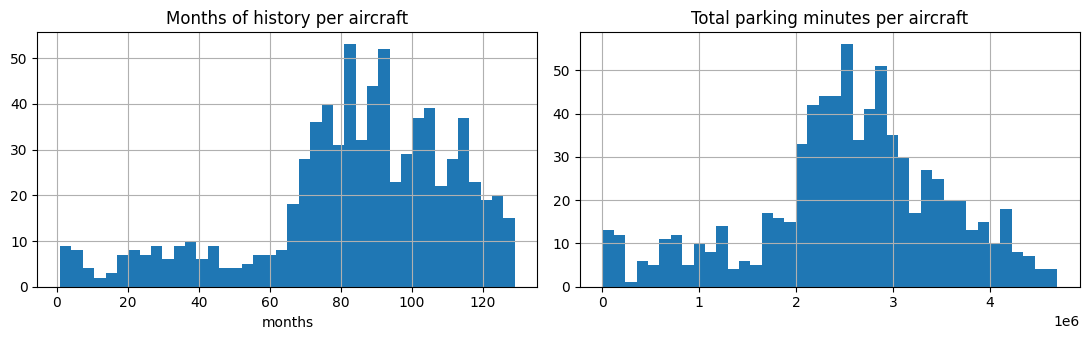

In [13]:
# Distribution of history length
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
hist_len.hist(bins=40, ax=ax[0]); ax[0].set_title('Months of history per aircraft'); ax[0].set_xlabel('months')
per_ac['total_parking_min'].hist(bins=40, ax=ax[1]); ax[1].set_title('Total parking minutes per aircraft')
plt.tight_layout(); plt.show()

## 6. Group by month (`year_month`)
Fleet size over time (aircraft were delivered 2015–2024, so the active fleet should grow) and whether environmental drivers have a seasonal/temporal trend.

In [14]:
by_month = env_tr.groupby('year_month').agg(
    n_aircraft=('aircraft_id', 'nunique'),
    mean_humidity=('metar_relative_humidity', 'mean'),
    mean_temp_c=('metar_temperature_c', 'mean'),
    mean_parking=('total_parking_minutes', 'mean'),
).reset_index()
by_month['year_month'] = pd.PeriodIndex(by_month['year_month'], freq='M').to_timestamp()
by_month = by_month.sort_values('year_month')
by_month.head()

,year_month,n_aircraft,mean_humidity,mean_temp_c,mean_parking
0,2014-04-01,1,57.726824,22.820806,27355.950000
1,2014-05-01,1,53.882236,24.082117,42955.383333
2,2014-06-01,1,64.338607,26.304374,40983.750000
3,2014-07-01,1,66.487114,23.397447,39324.683333
4,2014-08-01,1,60.362067,27.014980,41755.583333


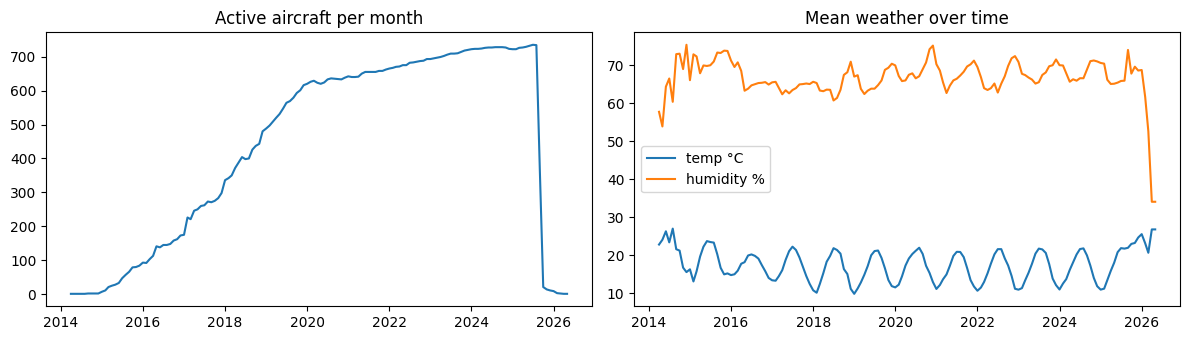

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].plot(by_month['year_month'], by_month['n_aircraft']); ax[0].set_title('Active aircraft per month')
ax[1].plot(by_month['year_month'], by_month['mean_temp_c'], label='temp °C')
ax[1].plot(by_month['year_month'], by_month['mean_humidity'], label='humidity %')
ax[1].legend(); ax[1].set_title('Mean weather over time')
plt.tight_layout(); plt.show()

### 6.1 Corrosion observations over time
When do the first-corrosion events cluster? (by observation year)

In [16]:
corr['obs_year'] = corr['observation_date'].dt.year
corr['obs_year'].value_counts().sort_index()

obs_year
2016      2
2017      6
2018     15
2019     24
2020     35
2021     90
2022    100
2023    113
2024    162
2025    184
2026     59
Name: count, dtype: int64

## 7. Integrity checks (reproduce the verified facts)
Asserting the §3.1 facts so this notebook fails loudly if the data ever changes.

In [17]:
tr_ids = set(env_tr.aircraft_id); te_ids = set(env_te.aircraft_id); c_ids = set(corr.aircraft_id)
orphans = c_ids - tr_ids
print('env-train aircraft without a corrosion record :', len(tr_ids - c_ids))
print('corrosion orphans (not in env-train)          :', len(orphans))
print('   ...of those, also absent from env-test     :', len(orphans - te_ids))
print('train/test aircraft overlap                   :', len(tr_ids & te_ids))
print('duplicate (id, month) in env-train            :', env_tr.duplicated(['aircraft_id','year_month']).sum())
print('duplicate (id, month) in env-test             :', env_te.duplicated(['aircraft_id','year_month']).sum())

assert tr_ids <= c_ids
assert len(orphans - te_ids) == len(orphans)  # orphans absent from test too
assert len(tr_ids & te_ids) == 0
assert env_tr.duplicated(['aircraft_id','year_month']).sum() == 0
print('\nAll integrity checks passed.')

env-train aircraft without a corrosion record : 0
corrosion orphans (not in env-train)          : 32
   ...of those, also absent from env-test     : 32
train/test aircraft overlap                   : 0
duplicate (id, month) in env-train            : 0
duplicate (id, month) in env-test             : 0

All integrity checks passed.


## 8. Takeaway
- All 758 training-env aircraft have a corrosion record; **32 orphan** corrosion aircraft (no env history anywhere) are dropped below.
- `(aircraft_id, year_month)` is unique; train/test are disjoint.

Build the clean working set for the next notebook:

In [18]:
corr_clean = corr[corr.aircraft_id.isin(tr_ids)].copy()
usable_aircraft = sorted(tr_ids)
print('usable training aircraft:', len(usable_aircraft))
print('corrosion rows after dropping orphans:', corr_clean.shape[0])

usable training aircraft: 758
corrosion rows after dropping orphans: 758


> Next: [`02_target_construction.ipynb`](02_target_construction.ipynb) — build the (1 / 0) labels.